### **Análise Exploratória**

In [5]:
import sys
sys.path.append('../')

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import os
from tqdm import tqdm
import ipywidgets
from pathlib import Path
import cv2
import numpy as np

from src.target.points import load_points


### **Import dos Vídeos**

In [3]:
# Caminho da pasta
VIDEO_DIR = Path(r"..\data\videos")

EXTENSIONS = ["*.avi",]

In [4]:
# Verificando Número de Vídeos
video_paths = []

for ext in EXTENSIONS:
    video_paths.extend(VIDEO_DIR.glob(ext))

video_paths = sorted(video_paths)

print(f"Total de vídeos encontrados: {len(video_paths)}")

Total de vídeos encontrados: 235


In [5]:
# Levantamento de estatísticas dos vídeos
def analyze_video(video_path):
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"Erro ao abrir {video_path.name}")
        return None
    
    # Informações básicas
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Histograma acumulado
    hist_list = []
    
    frame_count = 0
    
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        hist = cv2.calcHist([gray], [0], None, [256], [0,256]).flatten()
        hist_list.append(hist)
        
        frame_count += 1
    
    cap.release()
    
    return {
        "filename": video_path.name,
        "fps": fps,
        "width": width,
        "height": height,
        "total_frames": total_frames,
        "mean_histogram": hist_list
    }

In [6]:
# Análises das Medidas Extraídas

results = []

for video_path in tqdm(video_paths):
    data = analyze_video(video_path)
    if data is not None:
        results.append(data)

dfVideos = pd.DataFrame(results)

print("Análise concluída.")
dfVideos[["filename", "fps", "width", "height", "total_frames"]]

100%|██████████| 235/235 [04:15<00:00,  1.09s/it]

Análise concluída.


,filename,fps,width,height,total_frames
0,1.avi,30.0,512,512,182
1,10.avi,30.0,1024,1024,92
2,100.avi,30.0,1024,1024,75
3,101.avi,30.0,1024,1024,217
4,102.avi,30.0,1024,1024,201
...,...,...,...,...,...
230,95.avi,30.0,512,512,143
231,96.avi,30.0,512,512,230
232,97.avi,30.0,1024,1024,112
233,98.avi,30.0,512,512,140


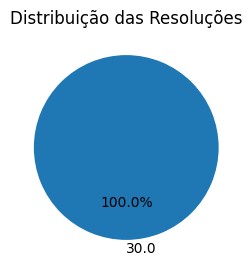

In [7]:
# Gráfico de Pizza do FPS
fps_counts = dfVideos["fps"].value_counts()

plt.figure(figsize=(3,3))
plt.pie(fps_counts,
        labels=fps_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribuição das Resoluções")
plt.show()

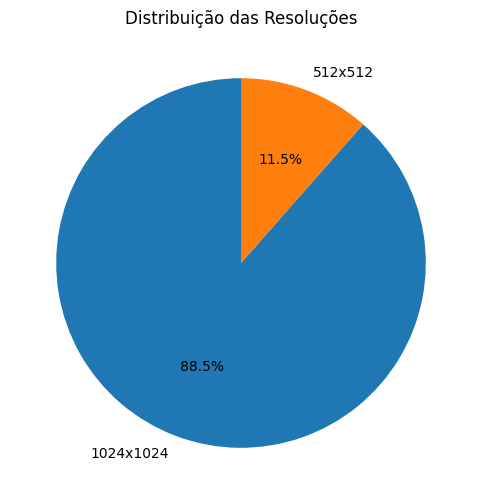

In [8]:
# Gráfico de Pizza das Resoluções
dfVideos["resolution"] = dfVideos["width"].astype(str) + "x" + dfVideos["height"].astype(str)

resolution_counts = dfVideos["resolution"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(resolution_counts,
        labels=resolution_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribuição das Resoluções")
plt.show()

In [9]:
# Verificando Vídeos com Resoluções 512x512: (Quais são?)
dfVideos = dfVideos.sort_values(
    by="filename",
    key=lambda col: col.str.extract(r"(\d+)").astype(int)[0]
)
videos_512x512 = list(dfVideos.loc[dfVideos["resolution"]=="512x512"].filename)
print(f"Vídeos com resolução 512x512:\n {videos_512x512}")
    

Vídeos com resolução 512x512:
 ['1.avi', '2.avi', '5.avi', '7.avi', '8.avi', '25.avi', '27.avi', '37.avi', '43.avi', '49.avi', '52.avi', '55.avi', '58.avi', '60.avi', '62.avi', '86.avi', '87.avi', '88.avi', '89.avi', '90.avi', '91.avi', '93.avi', '94.avi', '95.avi', '96.avi', '98.avi', '99.avi']


### **Import da Tabela Dados Selecionados**

In [7]:
# Importando Planilha de dados:
dfData = pd.read_csv(r"..\data\metadados\video_frame_metadata.csv")
dfData.shape

(973, 12)

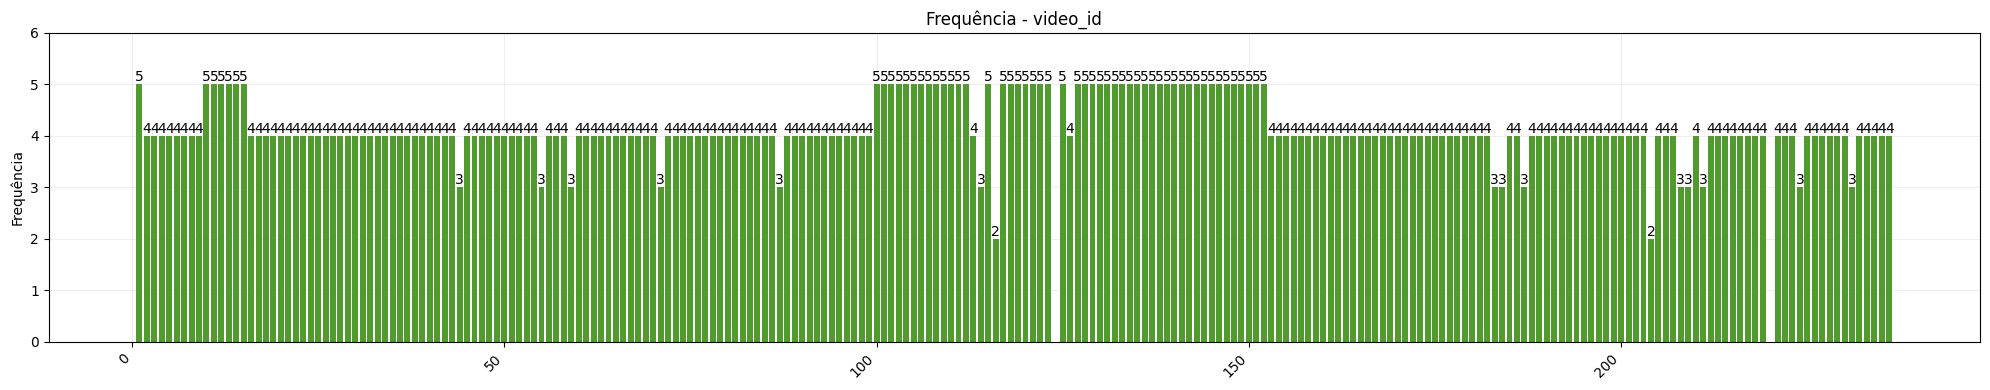

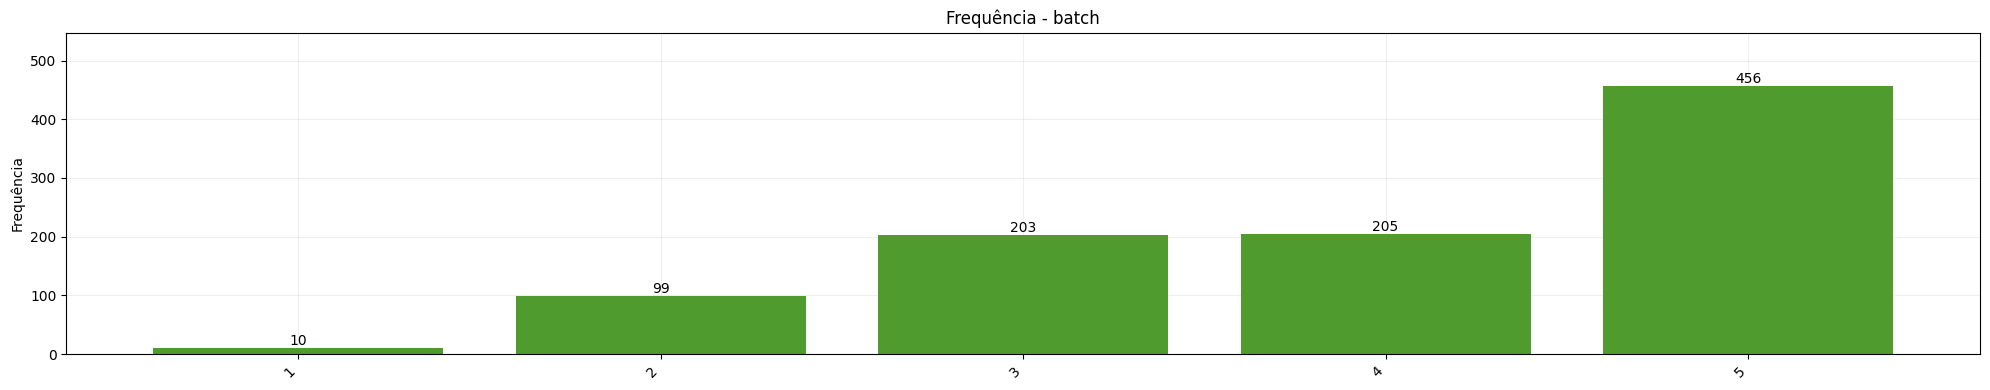

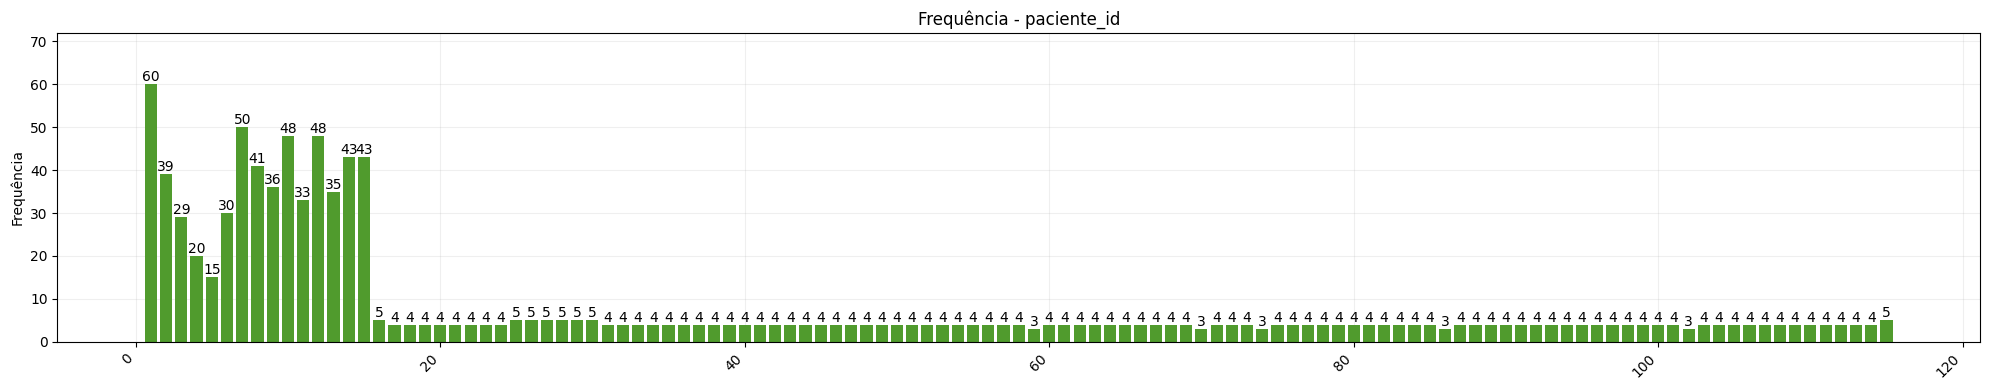

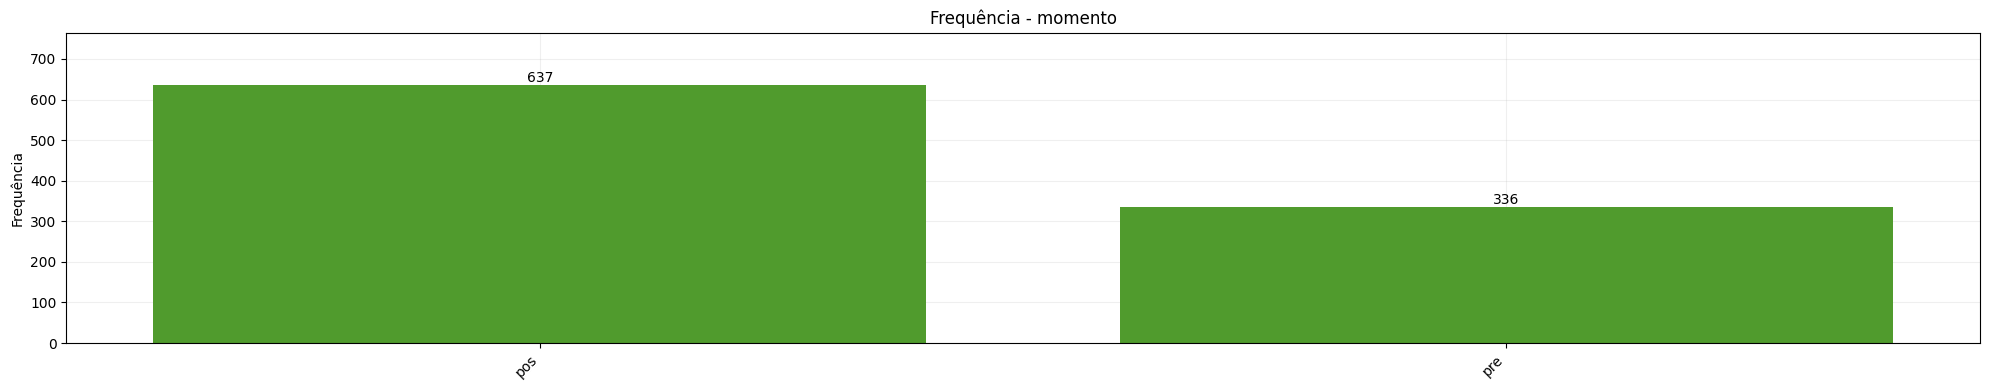

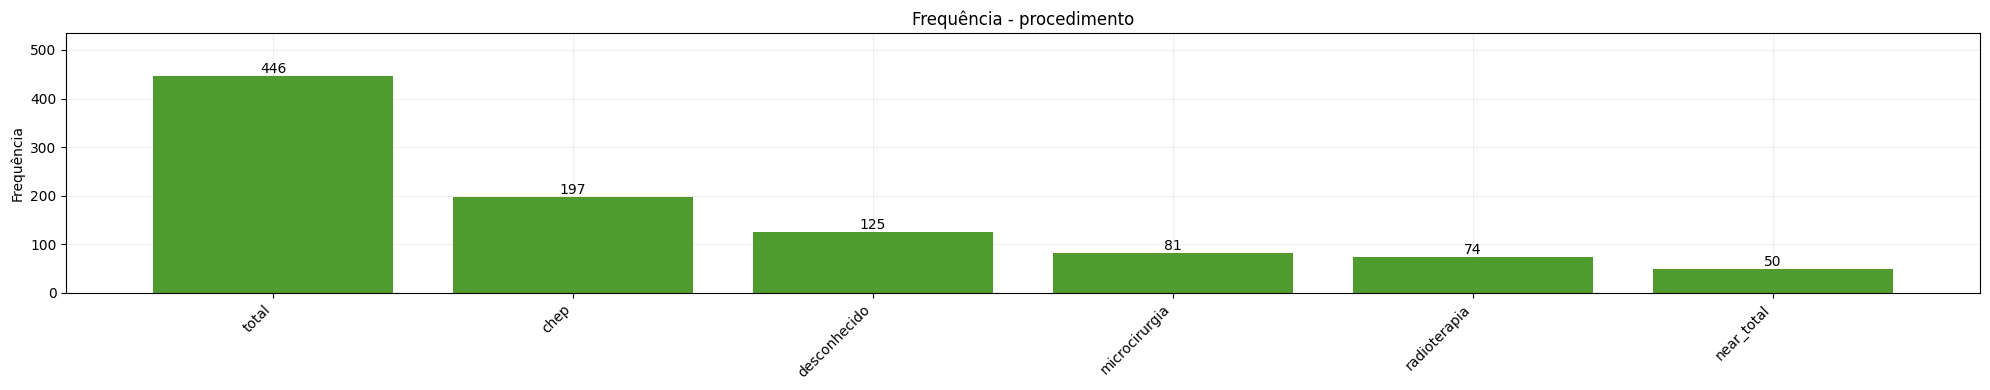

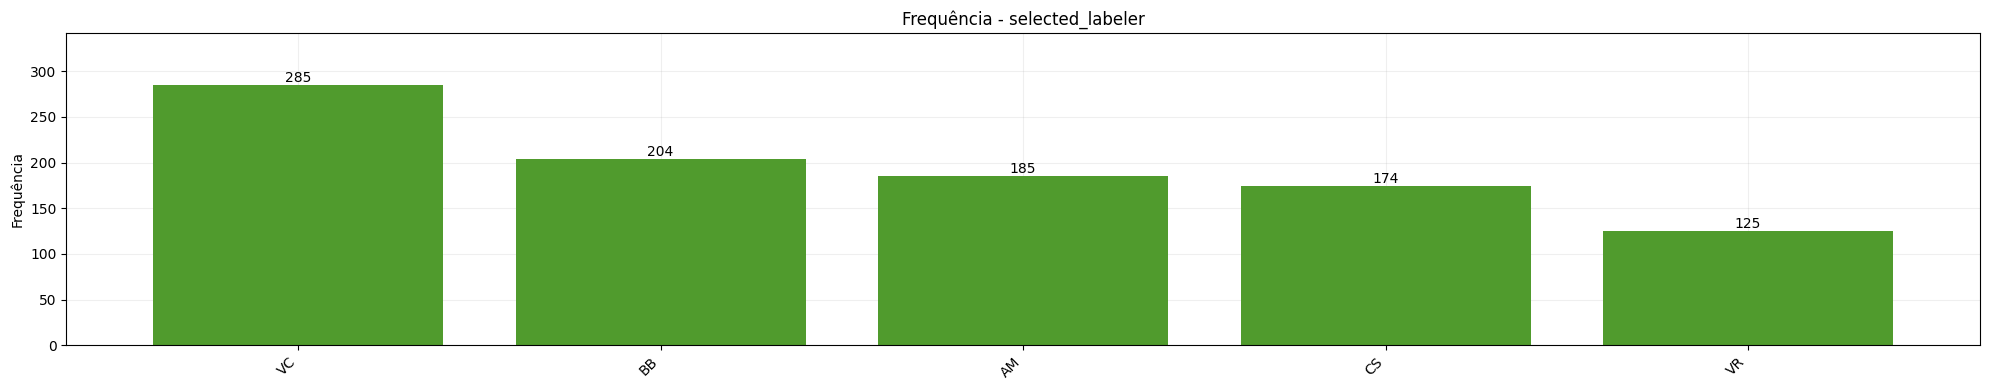

In [8]:
# Examinando Frequências:
def plot_frequency(df, col, title):

    dfFrequency = df[col].value_counts()
    labels = dfFrequency.index
    values = dfFrequency.values

    fig, ax = plt.subplots(figsize = (20,4))
    bar_plt = ax.bar(labels, values, color = "#509B2D", zorder=2.0)
    ax.set_ylabel("Frequência")
    ax.bar_label(bar_plt)
    ax.grid(alpha = 0.2, zorder=1.0)
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1.2 * max(values))
    plt.tight_layout()
    plt.show()

cols = ["video_id", "batch", "paciente_id", "momento", "procedimento", "selected_labeler"]
for col in cols:
    plot_frequency(dfData, col, title = f"Frequência - {col}")

### **Import dos Frames Selecionados**

In [12]:
# Caminho da pasta
IMAGE_DIR = Path(r"..\data\frames")

# Extensões aceitas
EXTENSIONS = ["*.tif", "*.tiff", "*.png"]

In [13]:
# Contando Imagens: 

image_paths = []

for ext in EXTENSIONS:
    image_paths.extend(IMAGE_DIR.glob(ext))

image_paths = sorted(image_paths)

print(f"Total de imagens encontradas: {len(image_paths)}")

Total de imagens encontradas: 941


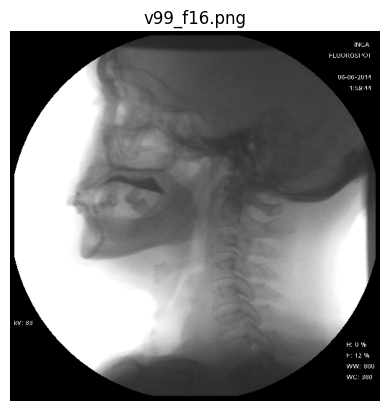

In [14]:
# Visualização de Algumas Imagens
def show_random_images(n=5):
    sample = np.random.choice(image_paths, n, replace=False)
    
    for path in sample:
        img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
        plt.figure()
        plt.imshow(img, cmap="gray")
        plt.title(path.name)
        plt.axis("off")
        plt.show()

show_random_images(1)

In [15]:
# Extraindo características por Imagens
def analyze_image(path, resize_to=None):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    
    if img is None:
        return None
    
    original_shape = img.shape
    
    if resize_to is not None:
        img = cv2.resize(img, resize_to)
    
    # Estatísticas básicas
    mean_intensity = np.mean(img)
    std_intensity = np.std(img)
    min_intensity = np.min(img)
    max_intensity = np.max(img)
    
    # Histograma
    hist = cv2.calcHist([img], [0], None, [256], [0,256]).flatten()
    
    return {
        "filename": path.name,
        "height": original_shape[0],
        "width": original_shape[1],
        "mean": mean_intensity,
        "std": std_intensity,
        "min": min_intensity,
        "max": max_intensity,
        "histogram": hist
    }

In [16]:
# Dados Estatísticos das imagens
results = []

for path in tqdm(image_paths):
    data = analyze_image(path)
    
    if data is not None:
        results.append(data)

dfFrames = pd.DataFrame(results)

print("Análise concluída.")
dfFrames[["mean", "std", "min", "max"]].describe()

100%|██████████| 941/941 [00:16<00:00, 55.57it/s] 

Análise concluída.


,mean,std,min,max
count,941.000000,941.000000,941.0,941.000000
mean,92.126687,82.716616,0.0,252.309245
std,18.123834,9.749619,0.0,6.650629
min,42.875271,42.225016,0.0,234.000000
25%,82.742885,78.713058,0.0,255.000000
50%,94.877032,84.886226,0.0,255.000000
75%,104.574674,89.279525,0.0,255.000000
max,122.512972,100.613011,0.0,255.000000


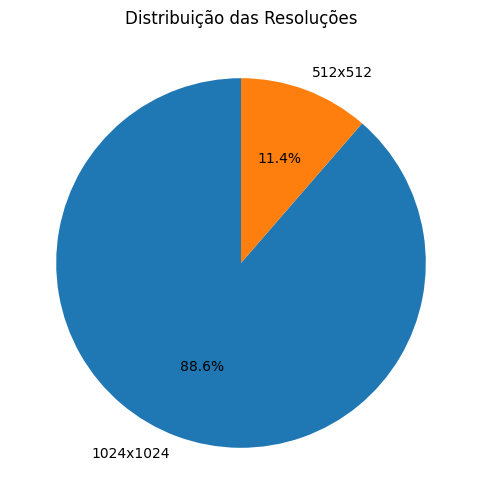

In [17]:
# Gráfico de Pizza das Resoluções
dfFrames["resolution"] = dfFrames["width"].astype(str) + "x" + dfFrames["height"].astype(str)

resolution_counts = dfFrames["resolution"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(resolution_counts,
        labels=resolution_counts.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Distribuição das Resoluções")
plt.show()

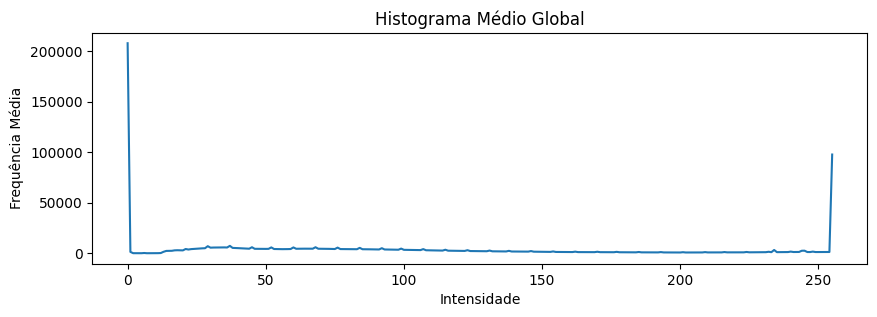

In [18]:
# Análise Histograma Estacado
all_histograms = np.stack(dfFrames["histogram"].values)
mean_histogram = np.mean(all_histograms, axis=0)

plt.figure(figsize = (10, 3))
plt.plot(mean_histogram)
plt.title("Histograma Médio Global")
plt.xlabel("Intensidade")
plt.ylabel("Frequência Média")
plt.show()

### **Possíveis Processamentos**

In [ ]:
# Examinando histogramas por frame

# Ideia -> Grafico interativo para ver como o histograma muda de frame para frame



In [ ]:
# Examinando histogramas por vídeo

# Ideia -> Histograma mostrando o vídeo inteiro (histograma estacado), pensando como se fosse um único grande frame.
# A equalização seria com base no vídeo inteiro. 


### **Análise das Marcações de Pontos**

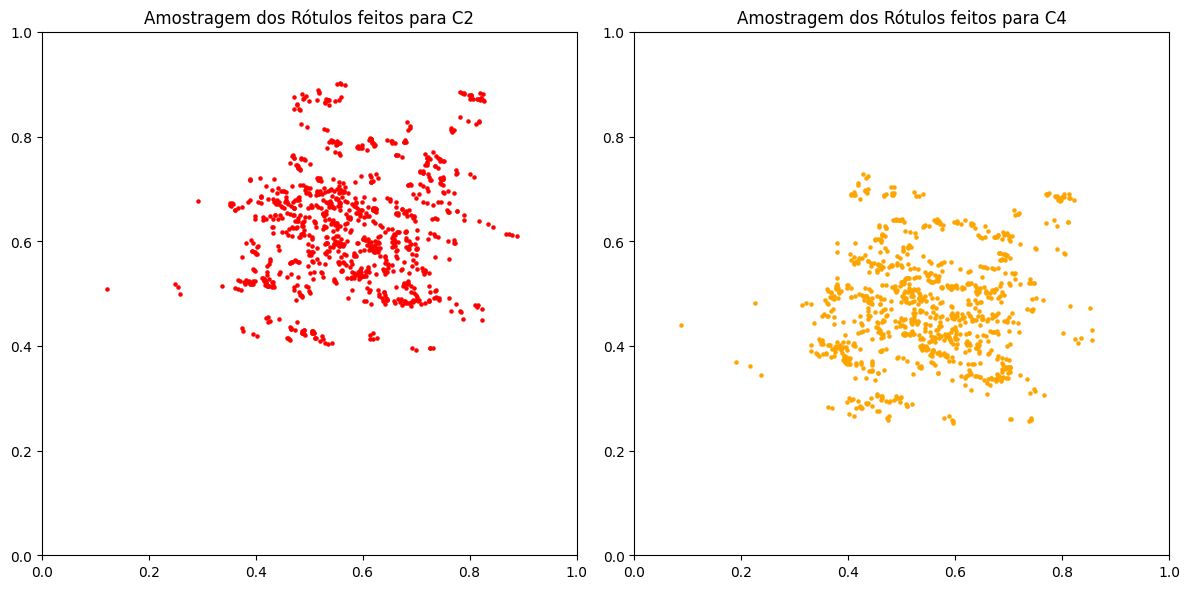

In [28]:
# Dispersão das marcações de vértebras

pontos_C2x = []
pontos_C2y = []
pontos_C4x = []
pontos_C4y = []
for i in range(dfData.shape[0]):
    dfAux = dfData.iloc[i]

    frame = cv2.imread(str(dfAux["frame_path"]), cv2.IMREAD_GRAYSCALE)
    lado = frame.shape[0]
    pontos = load_points(dfAux["target_dir"])

    #[C2, C4]
    if pontos[0][1] > pontos[1][1]:
        pontos_C2x.append(pontos[0][0]/lado)
        pontos_C2y.append(pontos[0][1]/lado)
        pontos_C4x.append(pontos[1][0]/lado)
        pontos_C4y.append(pontos[1][1]/lado)
    #[C4, C2]
    else:
        pontos_C4x.append(pontos[0][0]/lado)
        pontos_C4y.append(pontos[0][1]/lado)
        pontos_C2x.append(pontos[1][0]/lado)
        pontos_C2y.append(pontos[1][1]/lado)

fig, ax = plt.subplots(1,2, figsize = (12,6))

ax[0].scatter(pontos_C2x, pontos_C2y, color = "red", s = 5)
ax[0].set_ylim(0,1)
ax[0].set_xlim(0,1)
ax[0].set_title("Amostragem dos Rótulos feitos para C2")

ax[1].scatter(pontos_C4x, pontos_C4y, color = "orange", s = 5)
ax[1].set_ylim(0,1)
ax[1].set_xlim(0,1)
ax[1].set_title("Amostragem dos Rótulos feitos para C4")

plt.tight_layout()
plt.show()